In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Salary_Data.csv")

In [4]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [5]:
df.shape

(30, 2)

In [6]:
df = pd.read_csv("Salary_Data.csv")
df.head()
df.shape

(30, 2)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 608.0 bytes


In [8]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

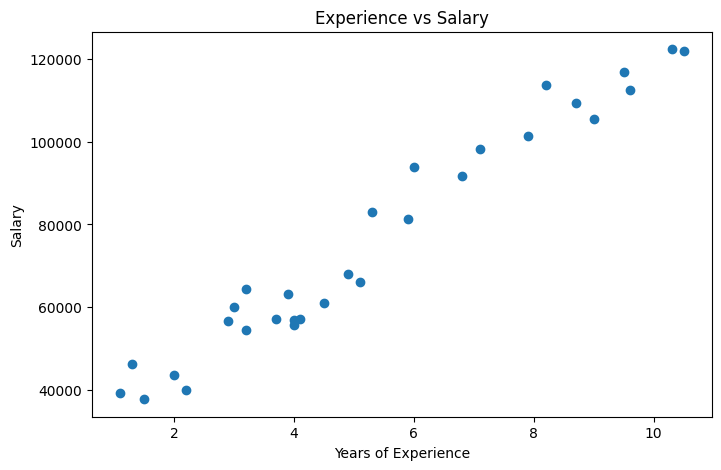

In [9]:
plt.figure(figsize=(8,5))

plt.scatter(df['YearsExperience'], df['Salary'])

plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Experience vs Salary')

plt.show()

In [10]:
X = df[['YearsExperience']]

y = df['Salary']

In [11]:
X.shape

(30, 1)

In [12]:
y.shape

(30,)

In [13]:
X = df[['YearsExperience']]
y = df['Salary']

X.shape
y.shape

(30,)

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
X_train.shape

(24, 1)

In [18]:
X_test.shape

(6, 1)

In [19]:
y_train.shape

(24,)

In [20]:
y_test.shape

(6,)

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
model = LinearRegression()

In [23]:
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
print("Training completed")

Training completed


In [27]:
y_pred = model.predict(X_test)

In [28]:
y_pred

array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

In [29]:
comparison = pd.DataFrame({
    'Actual Salary': y_test,
    'Predicted Salary': y_pred
})

comparison

,Actual Salary,Predicted Salary
27,112635.0,115790.210113
15,67938.0,71498.278095
23,113812.0,102596.868661
17,83088.0,75267.804224
8,64445.0,55477.792045
9,57189.0,60189.699707


In [30]:
from sklearn.metrics import mean_absolute_error, r2_score

In [31]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 6286.453830757749
R2 Score: 0.9024461774180497


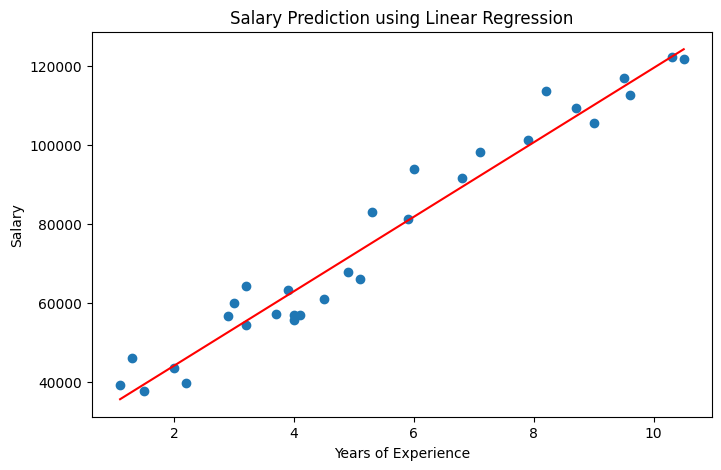

In [32]:
plt.figure(figsize=(8,5))

plt.scatter(X, y)

plt.plot(X, model.predict(X), color='red')

plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary Prediction using Linear Regression')

plt.show()

In [34]:
import pickle

pickle.dump(
    model,
    open('salary_prediction_model.pkl', 'wb')
)

In [35]:
import os

os.path.exists('salary_prediction_model.pkl')

True